In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from src import baseClasses, systemClasses, sensorClasses, muxClasses
import datetime
import numpy as np
from tqdm import tqdm
import pickle
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
plt.style.use("style.mplstyle")

In [2]:
dataset = baseClasses.Data()

In [3]:
mask = (
    ((dataset.data.index > datetime.datetime(2024, 4, 30)) & (dataset.data.index < datetime.datetime(2024, 12, 10)))
)

dataset.data = dataset.data.loc[mask]
dataset.err = dataset.err.loc[mask]

In [4]:
tgrad = systemClasses.System(dataset=dataset, name="TGRAD")
apa = systemClasses.System(dataset=dataset, name="APA")
prm = systemClasses.System(dataset=dataset, name="PRM")
pipe = systemClasses.System(dataset=dataset, name="PIPE")
pp = systemClasses.System(dataset=dataset, name="PP")
hawai = systemClasses.System(dataset=dataset, name="HAWAI")
ga1 = systemClasses.System(dataset=dataset, name="GA-1")
ga2 = systemClasses.System(dataset=dataset, name="GA-2")

Initializing PIPE Sensors: 100%|██████████| 12/12 [00:02<00:00,  4.52sensor/s]


ERROR: Channel (TE0120) not found


Initializing GA-2 Sensors: 100%|██████████| 18/18 [00:03<00:00,  5.09sensor/s]


In [72]:
tgrad.calibrate(calibName="SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500")
apa.calibrate(calibName="FIRST_POFF_TGRAD_APA_PP_PRM_PIPE_CE_OFF_REC_OFF_HV_OFF_20240502_094500_20240502_100000")
prm.calibrate(calibName="FIRST_POFF_TGRAD_APA_PP_PRM_PIPE_CE_OFF_REC_OFF_HV_OFF_20240502_094500_20240502_100000")
pipe.calibrate(calibName="FIRST_POFF_TGRAD_APA_PP_PRM_PIPE_CE_OFF_REC_OFF_HV_OFF_20240502_094500_20240502_100000")
pp.calibrate(calibName="FIRST_POFF_TGRAD_APA_PP_PRM_PIPE_CE_OFF_REC_OFF_HV_OFF_20240502_094500_20240502_100000")
hawai.calibrate(calibName="SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500")

Equalizing TGRAD Sensors: 100%|██████████| 48/48 [00:07<00:00,  6.34sensor/s]
Calibrating TGRAD Sensors - Calibration Name: SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500: 100%|██████████| 48/48 [00:00<00:00, 105.50sensor/s]
Equalizing APA Sensors: 100%|██████████| 16/16 [00:01<00:00,  8.30sensor/s]
Calibrating APA Sensors - Calibration Name: FIRST_POFF_TGRAD_APA_PP_PRM_PIPE_CE_OFF_REC_OFF_HV_OFF_20240502_094500_20240502_100000: 100%|██████████| 16/16 [00:00<00:00, 105.44sensor/s]
Equalizing PRM Sensors: 100%|██████████| 6/6 [00:00<00:00,  6.08sensor/s]
Calibrating PRM Sensors - Calibration Name: FIRST_POFF_TGRAD_APA_PP_PRM_PIPE_CE_OFF_REC_OFF_HV_OFF_20240502_094500_20240502_100000: 100%|██████████| 6/6 [00:00<00:00, 96.14sensor/s]
Equalizing PIPE Sensors: 100%|██████████| 12/12 [00:02<00:00,  5.90sensor/s]


ERROR: Channel (TE0120) not found


Calibrating PIPE Sensors - Calibration Name: FIRST_POFF_TGRAD_APA_PP_PRM_PIPE_CE_OFF_REC_OFF_HV_OFF_20240502_094500_20240502_100000: 100%|██████████| 12/12 [00:00<00:00, 92.36sensor/s]
Equalizing PP Sensors: 100%|██████████| 2/2 [00:00<00:00,  6.75sensor/s]
Calibrating PP Sensors - Calibration Name: FIRST_POFF_TGRAD_APA_PP_PRM_PIPE_CE_OFF_REC_OFF_HV_OFF_20240502_094500_20240502_100000: 100%|██████████| 2/2 [00:00<00:00, 85.85sensor/s]
Equalizing HAWAI Sensors: 100%|██████████| 24/24 [00:03<00:00,  6.19sensor/s]
Calibrating HAWAI Sensors - Calibration Name: SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500: 100%|██████████| 24/24 [00:00<00:00, 106.04sensor/s]


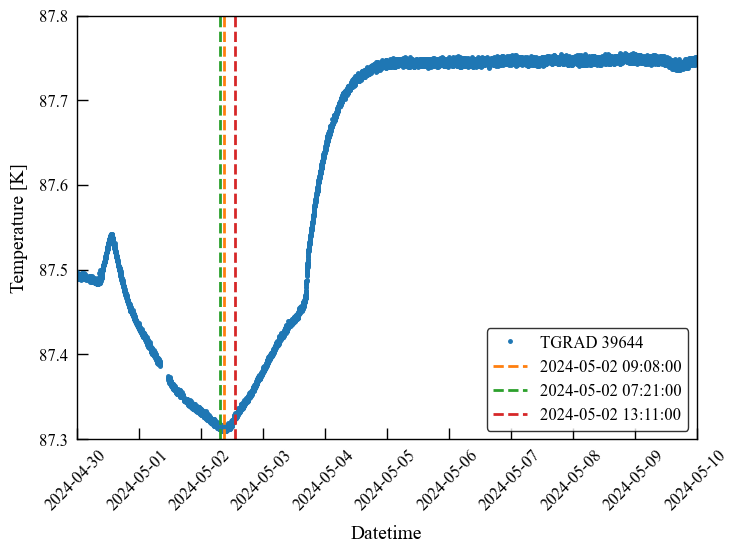

In [82]:
deltat = datetime.timedelta(minutes=60)
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(8, 5.5), sharex=True, sharey=True)
axes.plot(tgrad.sensors[39644].data.index.values, tgrad.sensors[39644].data.values, ".", label="TGRAD 39644", color="tab:blue")
axes.set_xlim(pd.Timestamp("2024-04-30 00:00:00"), pd.Timestamp("2024-05-10 00:00:00"))
axes.set_ylim(87.3,87.8)
t1, color1 = pd.Timestamp("2024-5-2 9:08:00"), "tab:orange"
axes.axvline(t1, color=color1, linestyle="--", label=f"{t1}")
t2, color2 = pd.Timestamp("2024-5-2 7:21:00"), "tab:green"
axes.axvline(t2, color=color2, linestyle="--", label=f"{t2}")
t3, color3 = pd.Timestamp("2024-5-2 13:11:00"), "tab:red"
axes.axvline(t3, color=color3, linestyle="--", label=f"{t3}")
axes.set_xlabel("Datetime")
axes.set_ylabel("Temperature [K]")
axes.legend()
axes.tick_params(axis='x', rotation=45);

/var/folders/2t/9f64gwx57z3375hyl7mpxd3h0000gn/T/ipykernel_67509/1650160476.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  profile["temp"].loc[(profile["Y"]>3960)] -= profile["temp"].loc[(profile["Y"]==3963)].values[0] - profile["temp"].loc[(profile["Y"]==3727)].values[0]


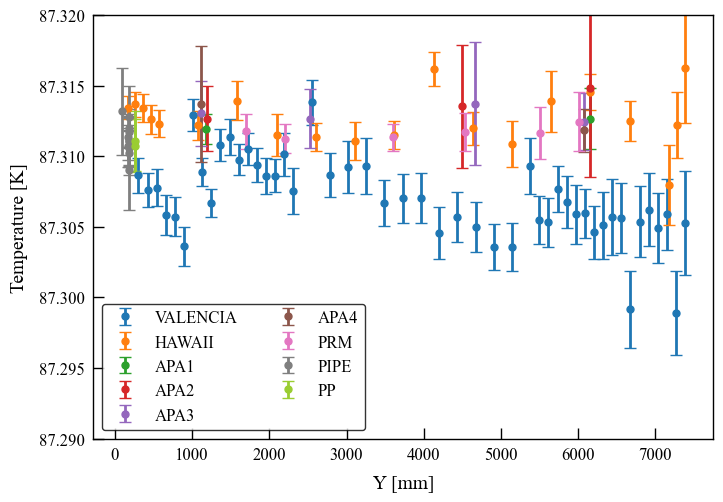

In [83]:
mask1 = apa.profiles["name"].str.contains("APA1", na=False) & ~apa.profiles["name"].str.contains("F", na=False)
mask2 = apa.profiles["name"].str.contains("APA2", na=False) & ~apa.profiles["name"].str.contains("F", na=False)
mask3 = apa.profiles["name"].str.contains("APA3", na=False) & ~apa.profiles["name"].str.contains("F", na=False)
mask4 = apa.profiles["name"].str.contains("APA4", na=False) & ~apa.profiles["name"].str.contains("F", na=False)

fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(6,6), sharex=True, sharey=True)
fig.set_size_inches(8, 5.5)
tgrad.makeProfiles(tini=t2, tend=t2 + deltat)
profile = tgrad.profiles
profile["temp"].loc[(profile["Y"]>3960)] -= profile["temp"].loc[(profile["Y"]==3963)].values[0] - profile["temp"].loc[(profile["Y"]==3727)].values[0]
axes.errorbar(profile["Y"].values, profile["temp"].values, yerr=profile["err"].values, fmt='o', label=f"VALENCIA", color="tab:blue")
hawai.makeProfiles(tini=t2, tend=t2 + deltat)
profile = hawai.profiles
axes.errorbar(profile["Y"].values, profile["temp"].values, yerr=profile["err"].values, fmt='o', label=f"HAWAII", color="tab:orange")
axes.set_xlabel("Y [mm]")
apa.makeProfiles(tini=t1, tend=t1 + deltat)
axes.errorbar(
    apa.profiles.loc[mask1, "Y"].values,
    apa.profiles.loc[mask1, "temp"].values,
    yerr=apa.profiles.loc[mask1, "err"].values,
    color="tab:green",
    fmt='o',
    label="APA1"
)
axes.errorbar(
    apa.profiles.loc[mask2, "Y"].values,
    apa.profiles.loc[mask2, "temp"].values,
    yerr=apa.profiles.loc[mask2, "err"].values,
    color="tab:red",
    fmt='o',
    label="APA2"
)
axes.errorbar(
    apa.profiles.loc[mask3, "Y"].values,
    apa.profiles.loc[mask3, "temp"].values,
    yerr=apa.profiles.loc[mask3, "err"].values,
    color="tab:purple",
    fmt='o',
    label="APA3"
)
axes.errorbar(
    apa.profiles.loc[mask4, "Y"].values,
    apa.profiles.loc[mask4, "temp"].values,
    yerr=apa.profiles.loc[mask4, "err"].values,
    color="tab:brown",
    fmt='o',
    label="APA4"
)
prm.makeProfiles(tini=t1, tend=t1 + deltat)
profile = prm.profiles
axes.errorbar(profile["Y"].values, profile["temp"].values, yerr=profile["err"].values, fmt='o', label="PRM", color="tab:pink")
pipe.makeProfiles(tini=t1, tend=t1 + deltat)
profile = pipe.profiles
axes.errorbar(profile["Y"].values, profile["temp"].values, yerr=profile["err"].values, fmt='o', label="PIPE", color="tab:grey")
pp.makeProfiles(tini=t1, tend=t1 + deltat)
profile = pp.profiles
axes.errorbar(profile["Y"].values, profile["temp"].values, yerr=profile["err"].values, fmt='o', label="PP", color="yellowgreen")
axes.set_ylabel("Temperature [K]")
axes.set_ylim(87.29, 87.32)
axes.legend(ncol=2)

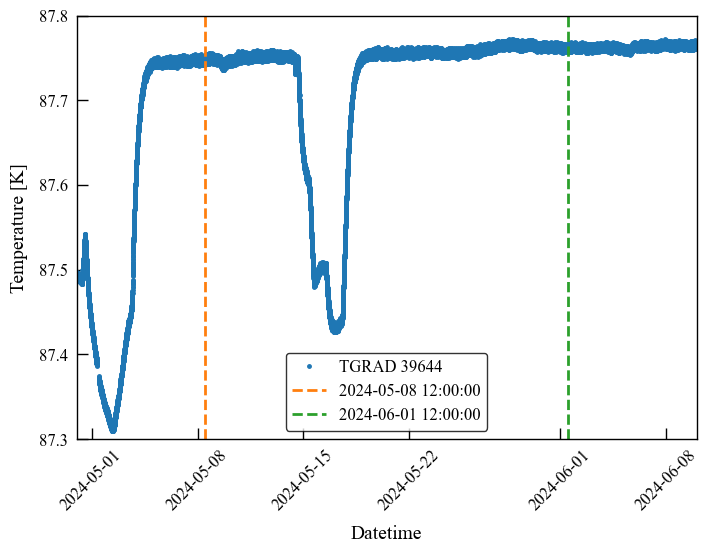

In [84]:
deltat = datetime.timedelta(minutes=60)
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(8, 5.5), sharex=True, sharey=True)
axes.plot(tgrad.sensors[39644].data.index.values, tgrad.sensors[39644].data.values, ".", label="TGRAD 39644", color="tab:blue")
axes.set_xlim(pd.Timestamp("2024-04-30 00:00:00"), pd.Timestamp("2024-06-10 00:00:00"))
axes.set_ylim(87.3,87.8)
t1, color1 = pd.Timestamp("2024-5-8 12:00:00"), "tab:orange"
t2, color2 = pd.Timestamp("2024-6-1 12:00:00"), "tab:green"
axes.axvline(t1, color=color1, linestyle="--", label=f"{t1}")
axes.axvline(t2, color=color2, linestyle="--", label=f"{t2}")
axes.set_xlabel("Datetime")
axes.set_ylabel("Temperature [K]")
axes.legend()
axes.tick_params(axis='x', rotation=45);

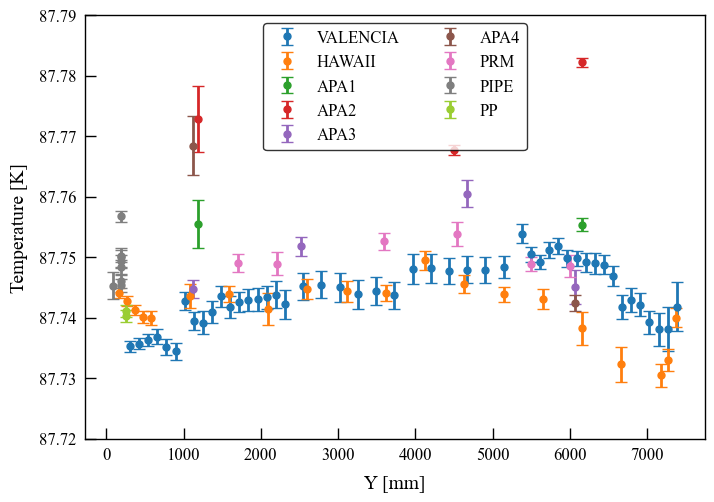

In [85]:
mask1 = apa.profiles["name"].str.contains("APA1", na=False) & ~apa.profiles["name"].str.contains("F", na=False)
mask2 = apa.profiles["name"].str.contains("APA2", na=False) & ~apa.profiles["name"].str.contains("F", na=False)
mask3 = apa.profiles["name"].str.contains("APA3", na=False) & ~apa.profiles["name"].str.contains("F", na=False)
mask4 = apa.profiles["name"].str.contains("APA4", na=False) & ~apa.profiles["name"].str.contains("F", na=False)

fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(6,6), sharex=True, sharey=True)
fig.set_size_inches(8, 5.5)
tgrad.makeProfiles(tini=t1, tend=t1 + deltat)
profile = tgrad.profiles
# profile["temp"].loc[(profile["Y"]>3960)] -= profile["temp"].loc[(profile["Y"]==3963)].values[0] - profile["temp"].loc[(profile["Y"]==3727)].values[0]
axes.errorbar(profile["Y"].values, profile["temp"].values, yerr=profile["err"].values, fmt='o', label=f"VALENCIA", color="tab:blue")
hawai.makeProfiles(tini=t2, tend=t2 + deltat)
profile = hawai.profiles
axes.errorbar(profile["Y"].values, profile["temp"].values - 0.016, yerr=profile["err"].values, fmt='o', label=f"HAWAII", color="tab:orange")
axes.set_xlabel("Y [mm]")
apa.makeProfiles(tini=t1, tend=t1 + deltat)
axes.errorbar(
    apa.profiles.loc[mask1, "Y"].values,
    apa.profiles.loc[mask1, "temp"].values,
    yerr=apa.profiles.loc[mask1, "err"].values,
    color="tab:green",
    fmt='o',
    label="APA1"
)
axes.errorbar(
    apa.profiles.loc[mask2, "Y"].values,
    apa.profiles.loc[mask2, "temp"].values,
    yerr=apa.profiles.loc[mask2, "err"].values,
    color="tab:red",
    fmt='o',
    label="APA2"
)
axes.errorbar(
    apa.profiles.loc[mask3, "Y"].values,
    apa.profiles.loc[mask3, "temp"].values,
    yerr=apa.profiles.loc[mask3, "err"].values,
    color="tab:purple",
    fmt='o',
    label="APA3"
)
axes.errorbar(
    apa.profiles.loc[mask4, "Y"].values,
    apa.profiles.loc[mask4, "temp"].values,
    yerr=apa.profiles.loc[mask4, "err"].values,
    color="tab:brown",
    fmt='o',
    label="APA4"
)
prm.makeProfiles(tini=t1, tend=t1 + deltat)
profile = prm.profiles
axes.errorbar(profile["Y"].values, profile["temp"].values, yerr=profile["err"].values, fmt='o', label="PRM", color="tab:pink")
pipe.makeProfiles(tini=t1, tend=t1 + deltat)
profile = pipe.profiles
axes.errorbar(profile["Y"].values, profile["temp"].values, yerr=profile["err"].values, fmt='o', label="PIPE", color="tab:grey")
pp.makeProfiles(tini=t1, tend=t1 + deltat)
profile = pp.profiles
axes.errorbar(profile["Y"].values, profile["temp"].values, yerr=profile["err"].values, fmt='o', label="PP", color="yellowgreen")
axes.set_ylabel("Temperature [K]")
axes.set_ylim(87.72, 87.79)
axes.legend(ncol=2)